# Trabajo Práctico 2 - Grupo 02

### Modelo Red Neuronal

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Dataset:** EDA aumentado 67k balanceado

**Hiperparámetros:** `lr=3e-05` | `epochs=2` | `max_length=128`

**Justificación:** LR de 2e-5 es el estándar recomendado para fine-tuning de BERT. Con el dataset balanceado de 67k, 3 épocas son suficientes para converger sin overfitting.

## 1. Instalación de dependencias


In [1]:
!pip3 install torch torchvision torchaudio
!pip3 install transformers datasets accelerate
!pip3 install spacy
!python3 -m spacy download es_core_news_sm
!pip3 install scikit-learn xgboost joblib
!pip3 install pandas numpy scipy
!pip3 install matplotlib seaborn
!pip3 install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requ

In [2]:
import nltk
nltk.download("sentiwordnet")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package sentiwordnet to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input/"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/santiagomoreyra/common/common/preprocessing.py
/kaggle/input/datasets/santiagomoreyra/common/common/evaluation.py
/kaggle/input/datasets/santiagomoreyra/common/common/data_utils.py
/kaggle/input/datasets/santiagomoreyra/common/common/io_utils.py
/kaggle/input/datasets/santiagomoreyra/common/common/embeddings.py
/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/sample_submission.csv
/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/train_augmented_eda_balanced.csv
/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/test.csv


## 2. Imports y configuración


In [4]:
import sys
sys.path.insert(0, "/kaggle/input/datasets/santiagomoreyra/common/")
sys.path.insert(0, "/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/")

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

MODEL_NAME  = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LENGTH  = 128
BATCH_SIZE  = 32
NUM_EPOCHS  = 2
LR          = 3e-5
CLASS_NAMES = ["negativa", "neutra", "positiva"]

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    print("GPU: Apple Silicon (MPS)")
else:
    print("GPU: No disponible, corriendo en CPU")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Carga de datos

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/train_augmented_eda_balanced.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/santiagomoreyra/tp2-ciencia-de-datos/test.csv")

print(f"Train (aumentado): {len(train_df):,} filas")
print(f"Distribucion:\n{train_df['label'].value_counts().sort_index()}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

print("\nAplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in X_train_raw])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train (aumentado): 67,000 filas
Distribucion:
label
0    22400
1    22200
2    22400
Name: count, dtype: int64

Aplicando clean_minimal...
Train: 53,600 | Val: 13,400 | Test: 8,500


## 4. Dataset y tokenización

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("Tokenizando...")
train_dataset = ResenasDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,    tokenizer, MAX_LENGTH)
print("Listo.")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizando...
Listo.


## 5. Modelo y métricas


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg": float(f1_per[0]),
        "f1_neu": float(f1_per[1]),
        "f1_pos": float(f1_per[2]),
    }

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

## 6. Fine-tuning

In [8]:
OUTPUT_DIR = Path("models/red_neuronal_beto_n8_eda67k_lr3e5_ep2")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning: lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH} | dataset=EDA_67k_balanceado")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Iniciando fine-tuning: lr=3e-05 | epochs=2 | max_length=128 | dataset=EDA_67k_balanceado


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,1.140899,1.100998,0.767068,0.782751,0.685249,0.833204
2,0.851789,1.062989,0.785612,0.811249,0.696627,0.848959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1676, training_loss=1.0870548603358303, metrics={'train_runtime': 1365.5583, 'train_samples_per_second': 78.503, 'train_steps_per_second': 1.227, 'total_flos': 7051439595110400.0, 'train_loss': 1.0870548603358303, 'epoch': 2.0})

## 7. Evaluación en validación


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== red_neuronal_beto_n8_eda67k_lr3e5_ep2 ===
Hiperparámetros: {'model': 'dccuchile/bert-base-spanish-wwm-cased', 'epochs': 2, 'lr': 3e-05, 'max_length': 128, 'batch_size': 32, 'dataset': 'eda_augmented_67k_balanced'}

F1-macro:  0.7856
Precision: 0.7855
Recall:    0.7874
Accuracy:  0.7878

              precision    recall  f1-score   support

    negativa     0.7870    0.8371    0.8112      4480
      neutra     0.7313    0.6651    0.6966      4440
    positiva     0.8382    0.8600    0.8490      4480

    accuracy                         0.7878     13400
   macro avg     0.7855    0.7874    0.7856     13400
weighted avg     0.7856    0.7878    0.7859     13400

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3750     625       105
neutra         848    2953       639
positiva       167     460      3853


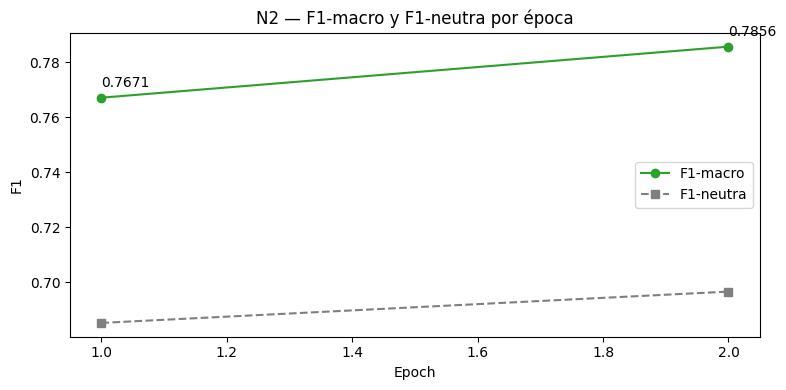

In [9]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate("red_neuronal_beto_n8_eda67k_lr3e5_ep2", y_val, y_pred,
         hyperparams={
             "model": MODEL_NAME,
             "epochs": NUM_EPOCHS,
             "lr": LR,
             "max_length": MAX_LENGTH,
             "batch_size": BATCH_SIZE,
             "dataset": "eda_augmented_67k_balanced",
         })

import matplotlib.pyplot as plt

history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(8, 4))
if eval_f1:
    epochs_list, f1s = zip(*eval_f1)
    ax.plot(epochs_list, f1s, marker="o", label="F1-macro", color="#2ca02c")
    for e, f in zip(epochs_list, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs_list, f1s = zip(*eval_neu)
    ax.plot(epochs_list, f1s, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_title("N2 — F1-macro y F1-neutra por época")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Guardado del modelo

In [10]:
SAVE_DIR = Path("models/red_neuronal_beto_n8_eda67k_lr3e5_ep2_final")
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
print(f"Modelo guardado en {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en models/red_neuronal_beto_n8_eda67k_lr3e5_ep2_final


## 9. Submission a Kaggle


In [11]:
Path("submissions").mkdir(exist_ok=True)
preds_test  = trainer.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv("submissions/submission_red_neuronal_beto_n8_eda67k_lr3e5_ep2.csv", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/submission_red_neuronal_beto_n2_eda67k_lr2e5_ep3.csv  ({len(sub)} predicciones)")
print(f"Distribucion: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

Guardado: submissions/submission_red_neuronal_beto_n2_eda67k_lr2e5_ep3.csv  (8500 predicciones)
Distribucion: clase 0: 42.8%, clase 1: 16.0%, clase 2: 41.2%
